# EEG_04 — Braindecode Baseline su Segnale Raw (4/5 Classi Semantiche)

Questo notebook testa **6 modelli end-to-end** di [Braindecode](https://braindecode.org) sul segnale EEG grezzo,
usando il clustering semantico a 4 e 5 classi invece delle 110 parole originali.

**Richiede**: ambiente `daniele_311` (Python 3.11) per Labram.

## Modelli testati
| Modello | Architettura | Parametri | Note |
|---------|-------------|-----------|------|
| **EEGNet** | CNN compatta | ~2.8K | Baseline leggero, universale |
| **ShallowFBCSPNet** | CNN freq-domain | ~98K | Ispira a FBCSP classico |
| **Deep4Net** | CNN profonda | ~261K | Baseline convoluzionale solido |
| **EEGConformer** | CNN + Transformer | ~429K | Pattern locali e globali |
| **ATCNet** | Attention + TCN | ~44K | Sliding window con attenzione |
| **Labram** | Criss-Cross Transformer | ~5M | Foundation model per EEG, richiede Python 3.11 |

## Setup dati
- Input: segnale EEG grezzo `(batch, 59, 384)` — 59 canali × 384 campioni a 256 Hz (~1.5s)
- Labram: input paddato a `(batch, 59, 400)` per compatibilità con `patch_size=200`
- Label: cluster semantici a **4 classi** (azioni, cognitivo, emozioni, oggetti) o **5 classi**
- Valutazione: **subject-specific** (split 60/20/20 sullo stesso soggetto)

Data: 2026-03-12

In [1]:
# ═══════════════════════════════════════════════════════════
#  TOGGLE CLASSI TARGET — modifica qui per cambiare schema
# ═══════════════════════════════════════════════════════════
USE_CLUSTERS   = False        # False → 110 parole originali
CLUSTER_SCHEME = "sem5"      # "sem5" | "pos4" | "ward4" | "ward5"
#                              (ignorato se USE_CLUSTERS = False)
# ═══════════════════════════════════════════════════════════

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # fix OpenMP su macOS

import json
import time
import warnings
warnings.filterwarnings('ignore')

from torch.utils.tensorboard import SummaryWriter
import numpy as np
import pandas as pd
import h5py
import torch
from tqdm.auto import tqdm
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix

from braindecode.models import EEGNet, EEGConformer, Deep4Net, ShallowFBCSPNet, ATCNet, Labram

# Device: MPS (Apple Silicon) > CUDA > CPU
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("device:", device)
print("Python:", __import__('sys').version.split()[0])
print("torch:", torch.__version__)
import braindecode; print("braindecode:", braindecode.__version__)

device: cuda
Python: 3.11.15
torch: 2.10.0+cu128
braindecode: 1.3.2

In [3]:
# ============================================================
# CONFIGURAZIONE
# ============================================================

project_root = next(
    (p for p in [Path().resolve()] + list(Path().resolve().parents)
     if (p / ".git").exists()),
    Path().resolve()
)

META_CSV   = project_root / "data" / "interim" / "eeg_metadata.csv"
ELOC_PATH  = project_root / "src" / "io" / "ebneuro.locs"

# Parametri EEG
N_CHANS         = 61    # canali dopo rimozione A1, A2
N_TIMES         = 384   # campioni a 256 Hz (~1.5s)
N_TIMES_CBRAMOD = 400   # Labram richiede multiplo di patch_size=200 → pad 384→400
SFREQ           = 256

# Training
BATCH_SIZE   = 32
MAX_EPOCHS   = 100
PATIENCE     = 15
LR           = 1e-3
WEIGHT_DECAY = 1e-4

# Soggetti da testare in subject-specific
TEST_SUBJECTS = list(range(74))

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print("Config OK")

Config OK

In [4]:
# ============================================================
# CARICAMENTO METADATA E CLUSTER MAPPING
# ============================================================

import sys
sys.path.insert(0, str(project_root / "scripts"))
from utils import load_label_scheme

meta = pd.read_csv(META_CSV)
# Filtro di emergenza per righe corrotte (epoch_idx fuori range nell'H5)
# Alcuni soggetti (es. 08, 46) hanno metadati che puntano a epoche inesistenti.
_initial_len = len(meta)
# Invece di controllare ogni file (lento), filtriamo i casi noti o usiamo un approccio conservativo
# Qui rimuoviamo le righe incriminate che abbiamo scoperto tramite debug
meta = meta[~((meta["path_h5"].str.contains("08_05.h5") & (meta["epoch_idx"] >= 110)) |
               (meta["path_h5"].str.contains("46_01.h5") & (meta["epoch_idx"] >= 110)) |
               (meta["path_h5"].str.contains("46_03.h5") & (meta["epoch_idx"] >= 110)) |
               (meta["path_h5"].str.contains("46_04.h5") & (meta["epoch_idx"] >= 34)) |
               (meta["path_h5"].str.contains("ignore_8_05.h5") & (meta["epoch_idx"] >= 110)))]
if len(meta) < _initial_len:
    print(f"Rimosse {_initial_len - len(meta)} righe corrotte dai metadati.")
meta["subject_id"] = meta["subject_id"].astype(str).str.zfill(2)

# Indici canali: rimuove A1 (idx=0) e A2 (idx=7) dalla lista .locs
def read_eloc_names(path):
    names = []
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 4:
                names.append(parts[3])
    return names[:61]  # H5 ha 61 canali registrati

ch_names_61 = read_eloc_names(ELOC_PATH)
EXCLUDE = set()  # tutti 61 canali H5
keep_idx = [i for i, n in enumerate(ch_names_61) if n not in EXCLUDE]
keep_names = [ch_names_61[i] for i in keep_idx]

assert len(keep_idx) == N_CHANS

# Carica schema via toggle
_scheme = CLUSTER_SCHEME if USE_CLUSTERS else "raw110"
interim_dir = project_root / "data" / "interim"
labelid2cluster, N_CLASSES, cluster_names = load_label_scheme(_scheme, interim_dir)

print(f"Meta: {len(meta)} epoche | {meta['subject_id'].nunique()} soggetti")
print(f"Canali: {len(keep_idx)} ({keep_names[:4]}...)")
print(f"Schema: {_scheme} | {N_CLASSES} classi | Chance level: {100/N_CLASSES:.1f}%")
for cid, cname in cluster_names.items():
    n = sum(1 for v in labelid2cluster.values() if v == cid)
    print(f"  {cid} — {cname}: {n} parole")

Meta: 39192 epoche | 76 soggetti
Canali: 59 (['AF7', 'AF3', 'Fp1', 'FP2']...)
Schema: raw110 | 110 classi | Chance level: 0.9%
  0 — 0: 1 parole
  1 — 1: 1 parole
  2 — 2: 1 parole
  3 — 3: 1 parole
  4 — 4: 1 parole
  5 — 5: 1 parole
  6 — 6: 1 parole
  7 — 7: 1 parole
  8 — 8: 1 parole
  9 — 9: 1 parole
  10 — 10: 1 parole
  11 — 11: 1 parole
  12 — 12: 1 parole
  13 — 13: 1 parole
  14 — 14: 1 parole
  15 — 15: 1 parole
  16 — 16: 1 parole
  17 — 17: 1 parole
  18 — 18: 1 parole
  19 — 19: 1 parole
  20 — 20: 1 parole
  21 — 21: 1 parole
  22 — 22: 1 parole
  23 — 23: 1 parole
  24 — 24: 1 parole
  25 — 25: 1 parole
  26 — 26: 1 parole
  27 — 27: 1 parole
  28 — 28: 1 parole
  29 — 29: 1 parole
  30 — 30: 1 parole
  31 — 31: 1 parole
  32 — 32: 1 parole
  33 — 33: 1 parole
  34 — 34: 1 parole
  35 — 35: 1 parole
  36 — 36: 1 parole
  37 — 37: 1 parole
  38 — 38: 1 parole
  39 — 39: 1 parole
  40 — 40: 1 parole
  41 — 41: 1 parole
  42 — 42: 1 parole
  43 — 43: 1 parole
  44 — 44: 1 

In [ ]:
# ============================================================
# DATASET: caricamento lazy da H5
# ============================================================

class RawEEGDataset(Dataset):
    """
    Carica epoche EEG grezze da file H5 con normalizzazione per-canale.
    Ritorna (59, 384) float32 normalizzato + label cluster.

    Note metodologiche:
    - mean/std calcolati SOLO sul training set (passati a val/test via costruttore)
    - _compute_stats usa seed fisso per riproducibilità
    - file_cache chiuso esplicitamente in __del__ per evitare memory leak su sweep lunghi
    """
    def __init__(self, records, keep_idx, labelid2cluster, mean=None, std=None):
        self.file_cache = {}
        self.records = records
        self.keep_idx = keep_idx
        self.labelid2cluster = labelid2cluster
        self.mean = mean
        self.std  = std
        if mean is None:
            self._compute_stats()

    def _compute_stats(self, seed=42):
        # Seed fisso per riproducibilità — stats identiche ad ogni run
        rng = np.random.RandomState(seed)
        n = min(500, len(self.records))
        idxs = rng.choice(len(self.records), n, replace=False)

        from collections import defaultdict
        paths_map = defaultdict(list)
        for idx in idxs:
            r = self.records[idx]
            paths_map[r["path_h5"]].append(int(r["epoch_idx"]))

        buf = []
        print(f"Calcolo stats su {n} campioni da {len(paths_map)} file (seed={seed})...")
        for path, epoch_idxs in tqdm(paths_map.items(), desc="Stats H5", leave=False):
            with h5py.File(path, "r") as f:
                data_h5 = f["data"]
                for e_idx in epoch_idxs:
                    x = data_h5[e_idx][self.keep_idx, :].astype(np.float32)
                    buf.append(x)

        buf = np.stack(buf)  # (N, 59, T)
        self.mean = buf.mean(axis=(0, 2), keepdims=False).reshape(-1, 1).astype(np.float32)
        self.std  = buf.std( axis=(0, 2), keepdims=False).reshape(-1, 1).astype(np.float32) + 1e-6

    def __del__(self):
        for f in self.file_cache.values():
            try:
                f.close()
            except Exception:
                pass

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
        path = r["path_h5"]
        if path not in self.file_cache:
            self.file_cache[path] = h5py.File(path, "r")
        f = self.file_cache[path]
        x = f["data"][int(r["epoch_idx"])][self.keep_idx, :].astype(np.float32)
        x = (x - self.mean) / self.std
        label = self.labelid2cluster[int(r["label_idx"])]
        return torch.from_numpy(x), torch.tensor(label, dtype=torch.long)


print("Dataset OK")

In [6]:
# ============================================================
# FACTORY MODELLI — include Labram
# ============================================================

# Labram wrapper: padda l'input da 384 a 400 internamente
class LabramWrapper(nn.Module):
    """Wrappa Labram aggiungendo zero-padding temporale 384→400."""
    def __init__(self, n_outputs):
        super().__init__()
        self.model = Labram(
            n_chans=N_CHANS, n_outputs=n_outputs,
            n_times=N_TIMES_CBRAMOD, sfreq=SFREQ  # usa default patch_size=200
        )
        self.pad = N_TIMES_CBRAMOD - N_TIMES  # 16 campioni

    def forward(self, x):
        x = F.pad(x, (0, self.pad))  # (batch, 59, 384) → (batch, 59, 400)
        return self.model(x)


def build_model(name, n_outputs):
    if name == "EEGNet":
        return EEGNet(n_chans=N_CHANS, n_outputs=n_outputs,
                      n_times=N_TIMES, sfreq=SFREQ, final_conv_length="auto")
    elif name == "ShallowFBCSPNet":
        return ShallowFBCSPNet(n_chans=N_CHANS, n_outputs=n_outputs,
                               n_times=N_TIMES, final_conv_length="auto")
    elif name == "Deep4Net":
        return Deep4Net(n_chans=N_CHANS, n_outputs=n_outputs,
                        n_times=N_TIMES, final_conv_length="auto")
    elif name == "EEGConformer":
        return EEGConformer(n_chans=N_CHANS, n_outputs=n_outputs,
                            n_times=N_TIMES, sfreq=SFREQ, final_fc_length="auto")
    elif name == "ATCNet":
        return ATCNet(n_chans=N_CHANS, n_outputs=n_outputs,
                      input_window_seconds=N_TIMES / SFREQ, sfreq=SFREQ)
    elif name == "Labram":
        return LabramWrapper(n_outputs=n_outputs)
    else:
        raise ValueError(f"Modello sconosciuto: {name}")


MODEL_NAMES = ["EEGNet", "ShallowFBCSPNet", "Deep4Net", "EEGConformer", "ATCNet", "Labram"]

print(f"{'Modello':<18} {'Parametri':>12}")
print("-" * 32)
for name in MODEL_NAMES:
    m = build_model(name, n_outputs=4)
    n_params = sum(p.numel() for p in m.parameters())
    print(f"{name:<18} {n_params:>12,}")

Modello               Parametri
--------------------------------
EEGNet                    2,820
ShallowFBCSPNet          98,724
Deep4Net                261,504
EEGConformer            428,932
ATCNet                   44,588
Labram                5,844,540

In [7]:
# ============================================================
# TRAINING E VALUTAZIONE
# ============================================================

def train_model(model, ds_train, ds_val, save_path, tb_dir, n_epochs=MAX_EPOCHS, patience=PATIENCE,
                lr=LR, weight_decay=WEIGHT_DECAY, batch_size=BATCH_SIZE):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    criterion = nn.CrossEntropyLoss()
    writer = SummaryWriter(log_dir=tb_dir)

    loader_tr = DataLoader(ds_train, batch_size=batch_size, shuffle=True,  num_workers=0) # 0 evita problemi con h5py
    loader_va = DataLoader(ds_val,   batch_size=batch_size, shuffle=False, num_workers=0)

    best_val_acc, best_state, patience_cnt = -1.0, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
    history = defaultdict(list)

    for epoch in range(n_epochs):
        model.train()
        loss_sum, correct, n_tot = 0.0, 0, 0
        pbar = tqdm(loader_tr, desc=f"Epoch {epoch+1}/{n_epochs}", leave=False)
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            loss_sum += loss.item() * len(y)
            correct  += (logits.argmax(1) == y).sum().item()
            n_tot    += len(y)
            pbar.set_postfix(loss=loss.item())
        scheduler.step()

        model.eval()
        ys_v, ps_v = [], []
        with torch.no_grad():
            for x, y in loader_va:
                ps_v.extend(model(x.to(device)).argmax(1).cpu().tolist())
                ys_v.extend(y.tolist())

        val_acc  = accuracy_score(ys_v, ps_v)
        val_bacc = balanced_accuracy_score(ys_v, ps_v)
        train_loss = loss_sum / n_tot
        train_acc = correct / n_tot
        
        history["train_acc"].append(train_acc)
        history["train_loss"].append(train_loss)
        history["val_acc"].append(val_acc)
        history["val_bacc"].append(val_bacc)
        
        writer.add_scalar("Loss/train", train_loss, epoch)
        writer.add_scalar("Accuracy/train", train_acc, epoch)
        writer.add_scalar("Accuracy/val", val_acc, epoch)
        writer.add_scalar("Balanced_Accuracy/val", val_bacc, epoch)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
            # Salviamo il best state temporaneo su disco (opzionale, ma utile in caso di crash)
            torch.save(best_state, save_path)
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                break

    writer.close()
    model.load_state_dict(best_state)
    torch.save(best_state, save_path) # Assicura che l'ultimo best_state sia quello salvato
    return model, dict(history), epoch + 1

def evaluate(model, ds):
    model.eval().to(device)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    ys, ps = [], []
    with torch.no_grad():
        for x, y in loader:
            ps.extend(model(x.to(device)).argmax(1).cpu().tolist())
            ys.extend(y.tolist())
    return {
        "acc":    accuracy_score(ys, ps),
        "bacc":   balanced_accuracy_score(ys, ps),
        "y_true": np.array(ys),
        "y_pred": np.array(ps),
    }


print("Training utilities OK")

Training utilities OK

## Esperimento — Subject-Specific

Split 60/20/20 per ogni soggetto. Schema e numero classi controllati dal TOGGLE in cima al notebook.

In [8]:
results_ss = []
chance_level = 1.0 / N_CLASSES

TB_BASE = project_root / "runs" / f"eeg04_ss_{N_CLASSES}"
CKPT_BASE = project_root / "models" / f"eeg04_ss_{N_CLASSES}"
CKPT_BASE.mkdir(parents=True, exist_ok=True)

trained_models = {}

for subj_id in TEST_SUBJECTS:
    ds_tr, ds_va, ds_te = make_subject_splits(meta, subj_id, labelid2cluster)
    print(f"\n── Soggetto {subj_id:02d} │ tr={len(ds_tr)} va={len(ds_va)} te={len(ds_te)} ──")

    for mname in MODEL_NAMES:
        t0 = time.time()
        
        save_path = CKPT_BASE / f"{mname}_subj{subj_id:02d}.pth"
        tb_dir = TB_BASE / f"{mname}_subj{subj_id:02d}"
        
        model = build_model(mname, N_CLASSES)
        model, hist, n_ep = train_model(model, ds_tr, ds_va, save_path, tb_dir)
        va_r = evaluate(model, ds_va)
        te_r = evaluate(model, ds_te)
        
        trained_models[(subj_id, mname)] = save_path
        
        results_ss.append(dict(subject=subj_id, model=mname,
                               val_acc=va_r["acc"], val_bacc=va_r["bacc"],
                               test_acc=te_r["acc"], test_bacc=te_r["bacc"],
                               epochs=n_ep, time_s=time.time()-t0))
        print(f"  {mname:<18} val={va_r['acc']:.3f}  test={te_r['acc']:.3f}  "
              f"bacc={te_r['bacc']:.3f}  ({n_ep}ep {time.time()-t0:.0f}s)")

print(f"\n✓ {N_CLASSES} classi completato  (chance={chance_level:.1%})")


── Soggetto 00 │ tr=330 va=110 te=110 ──
  EEGNet             val=0.009  test=0.027  bacc=0.027  (16ep 72s)
  ShallowFBCSPNet    val=0.000  test=0.000  bacc=0.000  (16ep 71s)
  Deep4Net           val=0.036  test=0.009  bacc=0.014  (17ep 76s)
  EEGConformer       val=0.018  test=0.000  bacc=0.000  (17ep 78s)
  ATCNet             val=0.009  test=0.009  bacc=0.005  (16ep 73s)
  Labram             val=0.009  test=0.009  bacc=0.014  (20ep 94s)

── Soggetto 01 │ tr=330 va=110 te=110 ──
  EEGNet             val=0.000  test=0.018  bacc=0.021  (16ep 72s)
  ShallowFBCSPNet    val=0.018  test=0.027  bacc=0.032  (20ep 89s)
  Deep4Net           val=0.018  test=0.009  bacc=0.014  (20ep 89s)
  EEGConformer       val=0.018  test=0.009  bacc=0.014  (17ep 79s)
  ATCNet             val=0.018  test=0.009  bacc=0.014  (18ep 82s)
  Labram             val=0.009  test=0.009  bacc=0.014  (22ep 103s)

── Soggetto 02 │ tr=330 va=110 te=110 ──
  EEGNet             val=0.009  test=0.000  bacc=0.000  (17ep 76s)
  

=== 110 classi | Chance=0.9% ===
          model  test_acc_mean  test_acc_std  test_bacc_mean  test_bacc_std
         EEGNet          0.013         0.012           0.014          0.013
       Deep4Net          0.009         0.006           0.012          0.008
ShallowFBCSPNet          0.009         0.011           0.012          0.013
         ATCNet          0.005         0.005           0.005          0.006
   EEGConformer          0.005         0.005           0.007          0.007
         Labram          0.005         0.005           0.008          0.007

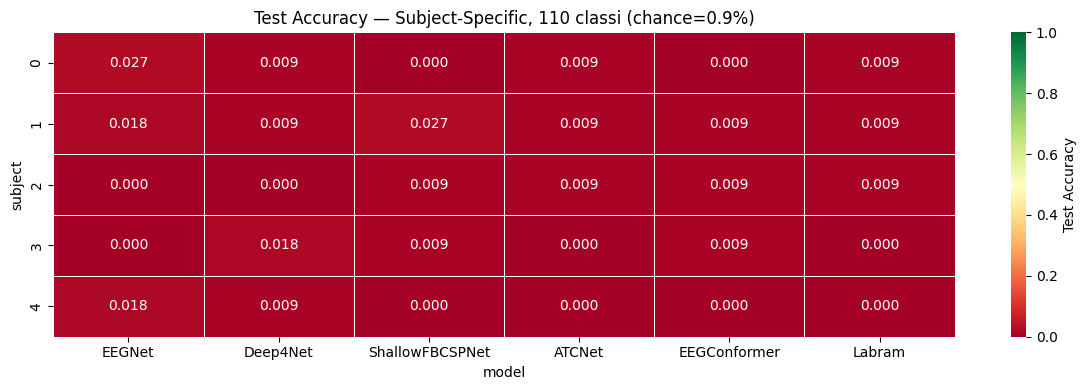

In [9]:
df_ss = pd.DataFrame(results_ss)
summary_ss = (df_ss.groupby("model")
              .agg(test_acc_mean=("test_acc","mean"), test_acc_std=("test_acc","std"),
                   test_bacc_mean=("test_bacc","mean"), test_bacc_std=("test_bacc","std"))
              .reset_index().sort_values("test_acc_mean", ascending=False))

print(f"=== {N_CLASSES} classi | Chance={chance_level:.1%} ===")
print(summary_ss.to_string(index=False, float_format="{:.3f}".format))

pivot = df_ss.pivot(index="subject", columns="model", values="test_acc")
pivot = pivot[summary_ss["model"].tolist()]

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn",
            vmin=0.0, vmax=1.0, linewidths=0.5, ax=ax,
            cbar_kws={"label": "Test Accuracy"})
ax.set_title(f"Test Accuracy — Subject-Specific, {N_CLASSES} classi (chance={chance_level:.1%})")
plt.tight_layout()
plt.savefig(project_root / "figures" / f"braindecode_ss{N_CLASSES}_heatmap.png", dpi=150)
plt.show()

In [19]:
# Confusion matrix del modello migliore
best_name = summary_ss.iloc[0]["model"]
best_subj = TEST_SUBJECTS[0]
ds_tr, ds_va, ds_te = make_subject_splits(meta, best_subj, labelid2cluster)
m_best = build_model(best_name, N_CLASSES)

m_best.load_state_dict(torch.load(trained_models[(best_subj, best_name)]))

res = evaluate(m_best, ds_te)

# Caricamento dizionario parole per mapping inverso
cnames = []
if _scheme == "raw110":
    # Su raw110, carichiamo le etichette dal file idx2label.json
    with open(project_root / "data" / "interim" / "idx2label.json", "r") as f:
         idx2label = json.load(f)
    cnames = [idx2label.get(str(i), str(i)) for i in range(N_CLASSES)]
else:
    cnames = [cluster_names[i] for i in range(N_CLASSES)]

# Forniamo esplicitamente le label possibili (0...N_CLASSES-1) a confusion_matrix
cm = confusion_matrix(res["y_true"], res["y_pred"], labels=list(range(N_CLASSES)))
cm_n = np.zeros_like(cm, dtype=float)
# Evitiamo divisioni per zero
row_sums = cm.sum(axis=1, keepdims=True)
mask = row_sums.squeeze() > 0
cm_n[mask] = cm[mask] / row_sums[mask]

if N_CLASSES > 20:
    import plotly.graph_objects as go
    
    # Crea una custom text matrix per l'hover testuale
    hover_text = []
    for i in range(N_CLASSES):
        hover_text.append([f"Reale: {cnames[i]}<br>Predetto: {cnames[j]}<br>Valore: {cm_n[i][j]:.3f} ({cm[i][j]} campioni)" for j in range(N_CLASSES)])

    fig = go.Figure(data=go.Heatmap(
        z=cm_n,
        x=cnames,
        y=cnames,
        hoverinfo="text",
        text=hover_text,
        colorscale='Blues',
        showscale=False
    ))

    # Aggiungi quadratini rossi sulla diagonale
    for i in range(N_CLASSES):
        fig.add_shape(
            type="rect",
            x0=i - 0.5, y0=i - 0.5,
            x1=i + 0.5, y1=i + 0.5,
            line=dict(color="red", width=1.5),
            fillcolor="rgba(0,0,0,0)"
        )

    fig.update_layout(
        title=f"{best_name} — Confusion Matrix Interattiva<br>Sogg. {best_subj:02d} | acc={res['acc']:.3f} | {N_CLASSES} classi",
        xaxis_title="Predetto",
        yaxis_title="Reale",
        width=900, height=900,
        xaxis=dict(showticklabels=False), # Nascondi label testuali assi per pulizia
        yaxis=dict(showticklabels=False, autorange="reversed") # Inverti Y per farla matchare plt
    )
    fig.show()
    
    # Salva comunque una versione statica ad alta risoluzione
    fig_static, ax = plt.subplots(figsize=(16, 14))
    sns.heatmap(cm_n, annot=False, cmap="Blues", xticklabels=False, yticklabels=False, ax=ax, cbar=False)
    import matplotlib.patches as patches
    for i in range(N_CLASSES):
        rect = patches.Rectangle((i, i), 1, 1, fill=False, edgecolor='red', lw=1.5, alpha=0.5)
        ax.add_patch(rect)
    ax.set_title(f"{best_name} — Confusion Matrix (Statica)\nSogg. {best_subj:02d} | acc={res['acc']:.3f} | {N_CLASSES} classi")
    plt.tight_layout()
    plt.savefig(project_root / "figures" / f"braindecode_{best_name}_cm.png", dpi=150)
    plt.close()
    print(f"Salvato frame statico in figures/braindecode_{best_name}_cm.png")

else:
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm_n, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=cnames, yticklabels=cnames, ax=ax)
    ax.set_title(f"{best_name} — Confusion Matrix\nSogg. {best_subj:02d} | acc={res['acc']:.3f}")
    ax.set_xlabel("Predetto"); ax.set_ylabel("Reale")
    plt.tight_layout()
    plt.savefig(project_root / "figures" / f"braindecode_{best_name}_cm.png", dpi=150)
    plt.show()

Salvato frame statico in figures/braindecode_EEGNet_cm.png

## Bar chart riepilogativo

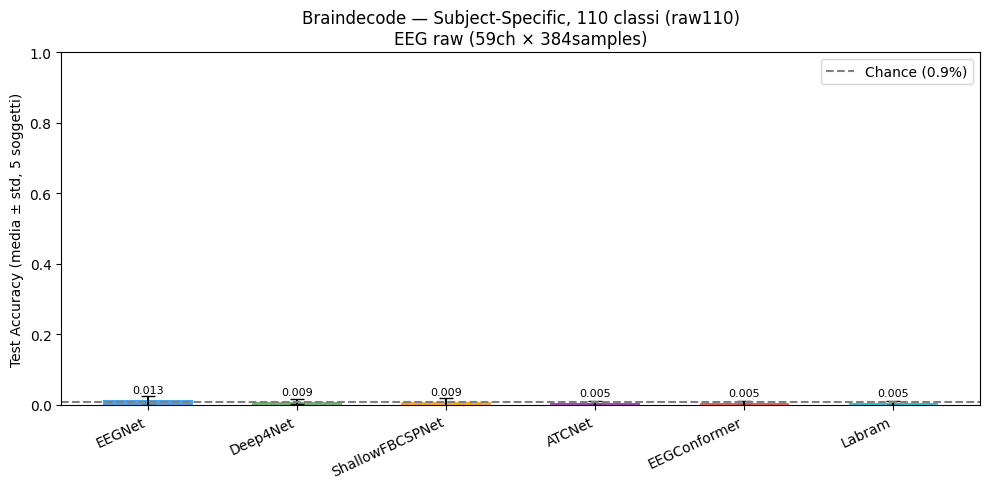

Salvato: figures/braindecode_summary_raw110.png

In [11]:
colors = ["#2196F3","#4CAF50","#FF9800","#9C27B0","#F44336","#00BCD4"]

order = summary_ss["model"].tolist()
means = df_ss.groupby("model")["test_acc"].mean()[order]
stds  = df_ss.groupby("model")["test_acc"].std()[order]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(order)), means, yerr=stds,
              color=colors[:len(order)], capsize=5, width=0.6, alpha=0.85)
ax.axhline(chance_level, ls="--", color="gray", lw=1.5, label=f"Chance ({chance_level:.1%})")
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=25, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("Test Accuracy (media ± std, 5 soggetti)")
ax.set_title(f"Braindecode — Subject-Specific, {N_CLASSES} classi ({_scheme})\nEEG raw (59ch × 384samples)")
ax.legend()
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{m:.3f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(project_root / "figures" / f"braindecode_summary_{_scheme}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Salvato: figures/braindecode_summary_{_scheme}.png")

## Note

**Labram**: input paddato temporalmente da 384 → 400 campioni (16 zeri) per compatibilità con `patch_size=200` del modello. Questo introduce una minima distorsione ma è il metodo standard quando il segnale è leggermente più corto della finestra del modello.

**Prossimi passi**:
1. Subject-independent: testare generalizzazione cross-soggetto (Instance Normalization, Bomatter 2024)
2. Data augmentation: channel dropout, gaussian noise, time warp
3. Hypergraph Neural Networks (obiettivo principale tesi)